# Token Prediction Analysis

This notebook evaluates the model's ability to predict specific target tokens in SMILES strings. By default, it analyzes chiral tokens (@ and @@) but can be configured to analyze any token type by modifying the TARGET_TOKEN_PATTERN or TARGET_TOKENS parameters.


In [1]:
import sys
import os

sys.path.append(os.path.abspath("../.."))
smiles_gpt_path = os.path.abspath("../../externals/smiles-gpt")
sys.path.append(smiles_gpt_path)
sys.path.append(
    os.path.join(
        os.environ.get("VIRTUAL_ENV", ""),
        "lib",
        "python3.12",
        "site-packages",
        "rdkit",
        "Contrib",
    )
)

In [2]:
MODEL_CHECKPOINT = "../../model/coconut_chiral_randomized/model.ckpt"
TOKENIZER_NAME = "kohbanye/SmilesTokenizer_PubChem_1M"
USE_HF_TOKENIZER = True

DATA_FILE = "../../data/coconut_chiral_test.smi"
N_SAMPLES = 10000
RANDOM_SEED = 42
BATCH_SIZE = 32
CANONICALIZE = True

# Target token configuration
# Can be a regex pattern (e.g., r'@+') or a list of specific tokens (e.g., ['[C@H]', '[C@@H]'])

# Example configurations:
# For chiral tokens:
# TARGET_TOKEN_PATTERN = r'@+'
# TARGET_TOKENS = None

# For common atoms + chiral tokens (testing generalization):
TARGET_TOKEN_PATTERN = None
TARGET_TOKENS = [
    "C",
    "N",
    "O",
    "c",
    "n",
    "o",
    "[C@H]",
    "[C@@H]",
    "[C@]",
    "[C@@]",
]  # Common atoms + chiral tokens

# Other examples:
# TARGET_TOKEN_PATTERN = r'='  # Double bonds
# TARGET_TOKEN_PATTERN = r'c'  # Aromatic carbons
# TARGET_TOKENS = ['(', ')', '[', ']']  # Structural tokens

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import torch
import torch.nn.functional as F
import random
import re
from rdkit import Chem

from npgpt import SmilesGptModel, SmilesGptTrainingConfig, get_tokenizer

# Set style
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

# Set random seeds
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

/home/5/uq02055/fs/git/npgpt/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Model and Tokenizer


In [4]:
# Load model and tokenizer using configuration
config = SmilesGptTrainingConfig()
tokenizer = get_tokenizer(config, TOKENIZER_NAME, from_hf=USE_HF_TOKENIZER)

model = SmilesGptModel.load_from_checkpoint(
    MODEL_CHECKPOINT,
    config=config,
    tokenizer=tokenizer,
    strict=False,
)
model = model.to("cuda")

model.eval()
print("Model loaded successfully")
print(f"Vocabulary size: {len(tokenizer)}")

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'RobertaTokenizer'. 
The class this function is called from is 'PreTrainedTokenizerFast'.


Model loaded successfully
Vocabulary size: 598


## Data Loading and Sampling


In [5]:
# Load data
print(f"Loading data from {DATA_FILE}...")
smiles_list = []
with open(DATA_FILE, "r") as f:
    for line in f:
        smiles = line.strip()
        if smiles:
            smiles_list.append(smiles)

# Sample data if needed
if len(smiles_list) > N_SAMPLES:
    print(f"Sampling {N_SAMPLES} molecules from {len(smiles_list)} total...")
    smiles_list = random.sample(smiles_list, N_SAMPLES)

print(f"Loaded {len(smiles_list)} SMILES strings")

Loading data from ../../data/coconut_chiral_test.smi...


Sampling 10000 molecules from 179112 total...
Loaded 10000 SMILES strings


In [6]:
def find_chiral_positions(smiles):
    """Find positions in SMILES where chiral centers (@ or @@) appear"""
    chiral_positions = []

    # Find all occurrences of @ and @@
    for match in re.finditer(r"@{1,2}", smiles):
        chiral_positions.append(
            {
                "position": match.start(),
                "token": match.group(),
                "length": len(match.group()),
            }
        )

    return chiral_positions


def find_target_tokens_in_vocab(tokenizer, target_tokens=None, pattern=None):
    """Find target tokens in the vocabulary based on pattern or explicit list."""
    found_tokens = {}

    # Get vocabulary
    if hasattr(tokenizer, "get_vocab"):
        vocab = tokenizer.get_vocab()
    elif hasattr(tokenizer, "vocab"):
        vocab = tokenizer.vocab
    else:
        print("Could not access tokenizer vocabulary")
        return found_tokens

    # Find tokens based on configuration
    if target_tokens is not None:
        # Use explicit token list
        for token in target_tokens:
            if token in vocab:
                found_tokens[token] = vocab[token]
    elif pattern is not None:
        # Use regex pattern
        for token, token_id in vocab.items():
            if re.search(pattern, token):
                found_tokens[token] = token_id
    else:
        print("Either target_tokens or pattern must be specified")
        return found_tokens

    return found_tokens


def extract_token_contexts(smiles, tokenizer, target_tokens, canonicalize=True):
    """Extract contexts where the model needs to predict target tokens."""
    if canonicalize:
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                return []
            smiles = Chem.MolToSmiles(mol, isomericSmiles=True, canonical=True)
        except Exception:
            return []

    # Tokenize the SMILES
    tokens = tokenizer.tokenize(smiles)
    if tokens is None:
        # Fallback for different tokenizer types
        encoded = tokenizer.encode(smiles, add_special_tokens=False)
        tokens = [tokenizer.decode([token_id]) for token_id in encoded]

    contexts = []

    # Find positions where target tokens appear
    for i, token in enumerate(tokens):
        if token in target_tokens:
            # Create context
            context = {
                "smiles": smiles,
                "position": i,
                "target_token": token,
                "prefix_tokens": tokens[:i],
                "suffix_tokens": tokens[i + 1 :] if i + 1 < len(tokens) else [],
                "prefix_smiles": "".join(tokens[:i]),
            }
            contexts.append(context)

    return contexts


# IMPORTANT: Re-run this cell and all cells below after changing TARGET_TOKENS or TARGET_TOKEN_PATTERN
print("=" * 60)
print("CONFIGURATION UPDATE")
print("=" * 60)
print(f"TARGET_TOKEN_PATTERN: {TARGET_TOKEN_PATTERN}")
print(f"TARGET_TOKENS: {TARGET_TOKENS}")
print()

# Test the function with current configuration
target_tokens = find_target_tokens_in_vocab(
    tokenizer, target_tokens=TARGET_TOKENS, pattern=TARGET_TOKEN_PATTERN
)
print(f"Found {len(target_tokens)} target tokens in vocabulary")
print("Sample target tokens:")
for token, token_id in list(target_tokens.items())[:10]:
    print(f"  {repr(token)}: {token_id}")

# Test context extraction
test_smiles = "C[C@H](O)CC[C@@H](N)C(=O)O"
test_contexts = extract_token_contexts(test_smiles, tokenizer, target_tokens)
print(f"\nTest SMILES: {test_smiles}")
print(f"Found {len(test_contexts)} target contexts:")
for i, ctx in enumerate(test_contexts):
    print(f"  {i + 1}. Position {ctx['position']}: '{ctx['target_token']}'")
    print(f"     Prefix: '{ctx['prefix_smiles']}'")

# Keep backward compatibility - create chiral_tokens alias
chiral_tokens = target_tokens

print("\n" + "=" * 60)
print("IMPORTANT: You need to re-run all cells below this one to see the new results!")
print("=" * 60)

CONFIGURATION UPDATE
TARGET_TOKEN_PATTERN: None
TARGET_TOKENS: ['C', 'N', 'O', 'c', 'n', 'o', '[C@H]', '[C@@H]', '[C@]', '[C@@]']

Found 10 target tokens in vocabulary
Sample target tokens:
  'C': 16
  'N': 23
  'O': 19
  'c': 15
  'n': 25
  'o': 44
  '[C@H]': 33
  '[C@@H]': 35
  '[C@]': 55
  '[C@@]': 56

Test SMILES: C[C@H](O)CC[C@@H](N)C(=O)O
Found 10 target contexts:
  1. Position 0: 'C'
     Prefix: ''
  2. Position 1: '[C@H]'
     Prefix: 'C'
  3. Position 3: 'O'
     Prefix: 'C[C@H]('
  4. Position 5: 'C'
     Prefix: 'C[C@H](O)'
  5. Position 6: 'C'
     Prefix: 'C[C@H](O)C'
  6. Position 7: '[C@@H]'
     Prefix: 'C[C@H](O)CC'
  7. Position 9: 'N'
     Prefix: 'C[C@H](O)CC[C@@H]('
  8. Position 11: 'C'
     Prefix: 'C[C@H](O)CC[C@@H](N)'
  9. Position 14: 'O'
     Prefix: 'C[C@H](O)CC[C@@H](N)C(='
  10. Position 16: 'O'
     Prefix: 'C[C@H](O)CC[C@@H](N)C(=O)'

IMPORTANT: You need to re-run all cells below this one to see the new results!


## Target Token Detection


## Extract Target Contexts from Dataset


In [7]:
def analyze_token_prediction(
    model, tokenizer, smiles, position, actual_token, target_tokens
):
    """Analyze model's prediction for target token at specific position"""
    try:
        # Get the tokenized version of the SMILES
        tokens = tokenizer.tokenize(smiles)
        if tokens is None:
            encoded = tokenizer.encode(smiles, add_special_tokens=False)
            tokens = [tokenizer.decode([token_id]) for token_id in encoded]

        # Get prefix tokens (everything before the target token)
        prefix_tokens = tokens[:position]
        prefix_smiles = "".join(prefix_tokens)

        # Encode the prefix
        input_ids = tokenizer.encode(
            prefix_smiles, add_special_tokens=True, truncation=True, max_length=512
        )
        input_ids = torch.tensor([input_ids]).to("cuda")

        # Get model predictions
        with torch.no_grad():
            outputs = model({"input_ids": input_ids, "labels": input_ids})
            logits = outputs.logits[0, -1, :]  # Get logits for the last token
            probs = F.softmax(logits, dim=-1)

        # Get probabilities for all target tokens
        target_probs = {}
        for token, token_id in target_tokens.items():
            target_probs[token] = probs[token_id].item()

        # Sort by probability
        sorted_target_probs = sorted(
            target_probs.items(), key=lambda x: x[1], reverse=True
        )

        # Get the top predicted target token
        if sorted_target_probs:
            predicted_token = sorted_target_probs[0][0]
            predicted_prob = sorted_target_probs[0][1]
        else:
            predicted_token = None
            predicted_prob = 0.0

        # Total target probability
        total_target_prob = sum(target_probs.values())

        # Check if prediction is correct
        is_correct = predicted_token == actual_token

        # Get actual token probability
        actual_token_prob = target_probs.get(actual_token, 0.0)

        # Get top 5 predictions
        top_5_predictions = sorted_target_probs[:5]

        return {
            "input_smiles": prefix_smiles,
            "actual_token": actual_token,
            "predicted_token": predicted_token,
            "is_correct": is_correct,
            "total_target_prob": total_target_prob,
            "actual_token_prob": actual_token_prob,
            "predicted_prob": predicted_prob,
            "top_5_predictions": top_5_predictions,
            "all_target_probs": target_probs,
        }

    except Exception as e:
        print(f"Error analyzing SMILES '{smiles}': {e}")
        import traceback

        traceback.print_exc()
        return None


# Test the function
if test_contexts:
    test_result = analyze_token_prediction(
        model,
        tokenizer,
        test_smiles,
        test_contexts[0]["position"],
        test_contexts[0]["target_token"],
        target_tokens,
    )
    if test_result:
        print("Test prediction result:")
        print(f"  Input: {test_result['input_smiles']}")
        print(
            f"  Actual: {test_result['actual_token']} (prob: {test_result['actual_token_prob']:.4f})"
        )
        print(
            f"  Predicted: {test_result['predicted_token']} (prob: {test_result['predicted_prob']:.4f})"
        )
        print(f"  Correct: {test_result['is_correct']}")
        print(f"  Total target prob: {test_result['total_target_prob']:.4f}")
        print(f"  Top 5 predictions:")
        for token, prob in test_result["top_5_predictions"]:
            print(f"    {token}: {prob:.4f}")

Test prediction result:
  Input: 
  Actual: C (prob: 0.0290)
  Predicted: C (prob: 0.0290)
  Correct: True
  Total target prob: 0.0604
  Top 5 predictions:
    C: 0.0290
    c: 0.0141
    [C@H]: 0.0046
    [C@@H]: 0.0045
    [C@]: 0.0023


In [8]:
# Extract all target contexts from the dataset
all_target_contexts = []
skipped_molecules = 0

print("Extracting target contexts from dataset...")
for smiles in tqdm(smiles_list):
    contexts = extract_token_contexts(
        smiles, tokenizer, target_tokens, canonicalize=CANONICALIZE
    )
    if contexts:
        all_target_contexts.extend(contexts)
    else:
        skipped_molecules += 1

print(
    f"\nExtracted {len(all_target_contexts)} target contexts from {len(smiles_list)} molecules"
)
print(f"Skipped {skipped_molecules} molecules without target tokens")

# Show statistics
from collections import defaultdict

target_token_counts = defaultdict(int)
for ctx in all_target_contexts:
    target_token_counts[ctx["target_token"]] += 1

print("\nTarget token distribution:")
for token, count in sorted(target_token_counts.items(), key=lambda x: -x[1])[:20]:
    print(f"  {repr(token)}: {count} ({count / len(all_target_contexts) * 100:.1f}%)")

# Keep backward compatibility
all_chiral_contexts = all_target_contexts

Extracting target contexts from dataset...


100%|██████████| 10000/10000 [00:05<00:00, 1746.38it/s]


Extracted 352388 target contexts from 10000 molecules
Skipped 3 molecules without target tokens

Target token distribution:
  'C': 162710 (46.2%)
  'c': 70915 (20.1%)
  'O': 67073 (19.0%)
  '[C@H]': 15323 (4.3%)
  '[C@@H]': 14146 (4.0%)
  'N': 10658 (3.0%)
  '[C@]': 3677 (1.0%)
  'n': 3231 (0.9%)
  '[C@@]': 3066 (0.9%)
  'o': 1589 (0.5%)


# Analyze all target contexts


In [9]:
# Analyze all target contexts
prediction_results = []
failed_predictions = 0

print(f"Analyzing {len(all_target_contexts)} target contexts...")
for ctx in tqdm(all_target_contexts):
    result = analyze_token_prediction(
        model,
        tokenizer,
        ctx["smiles"],
        ctx["position"],
        ctx["target_token"],
        target_tokens,
    )

    if result:
        # Add context information
        result.update(
            {
                "full_smiles": ctx["smiles"],
                "target_position": ctx["position"],
                "prefix_tokens": ctx.get("prefix_tokens", []),
                "suffix_tokens": ctx.get("suffix_tokens", []),
            }
        )
        prediction_results.append(result)
    else:
        failed_predictions += 1

print(f"\nSuccessfully analyzed {len(prediction_results)} target contexts")
print(f"Failed predictions: {failed_predictions}")

# Convert to DataFrame
results_df = pd.DataFrame(prediction_results)
print(f"\nResults DataFrame shape: {results_df.shape}")

Analyzing 352388 target contexts...


100%|██████████| 352388/352388 [30:23<00:00, 193.30it/s]



Successfully analyzed 352388 target contexts
Failed predictions: 0

Results DataFrame shape: (352388, 13)


In [10]:
if len(results_df) > 0:
    print("=== Token Prediction Analysis Results ===")

    # Overall accuracy
    overall_accuracy = results_df["is_correct"].mean()
    print(
        f"\nOverall Token Accuracy: {overall_accuracy:.3f} ({overall_accuracy * 100:.1f}%)"
    )

    # Accuracy by token type
    accuracy_by_token = results_df.groupby("actual_token")["is_correct"].agg(
        ["count", "mean"]
    )
    print("\nAccuracy by Target Token:")
    for token, stats in accuracy_by_token.iterrows():
        print(
            f"  {repr(token)}: {stats['mean']:.3f} ({stats['mean'] * 100:.1f}%) - {stats['count']} samples"
        )

    # Probability statistics
    print("\nProbability Statistics:")
    print(
        f"  Mean total target probability: {results_df['total_target_prob'].mean():.4f}"
    )
    print(
        f"  Mean actual token probability: {results_df['actual_token_prob'].mean():.4f}"
    )

    # Confidence analysis
    results_df["confidence"] = results_df["predicted_prob"]
    print("\nConfidence Statistics:")
    print(f"  Mean confidence: {results_df['confidence'].mean():.4f}")
    print(
        f"  Mean confidence (correct): {results_df[results_df['is_correct']]['confidence'].mean():.4f}"
    )
    print(
        f"  Mean confidence (incorrect): {results_df[~results_df['is_correct']]['confidence'].mean():.4f}"
    )

    # Top predicted tokens
    print("\nMost Frequently Predicted Target Tokens:")
    predicted_token_counts = results_df["predicted_token"].value_counts()
    for token, count in predicted_token_counts.head(10).items():
        accuracy = results_df[results_df["predicted_token"] == token][
            "is_correct"
        ].mean()
        print(
            f"  {repr(token)}: {count} times ({count / len(results_df) * 100:.1f}%), accuracy when predicted: {accuracy:.3f}"
        )

else:
    print("No results to analyze.")

=== Token Prediction Analysis Results ===

Overall Token Accuracy: 0.658 (65.8%)

Accuracy by Target Token:
  'C': 0.835 (83.5%) - 162710.0 samples
  'N': 0.456 (45.6%) - 10658.0 samples
  'O': 0.369 (36.9%) - 67073.0 samples
  '[C@@H]': 0.200 (20.0%) - 14146.0 samples
  '[C@@]': 0.084 (8.4%) - 3066.0 samples
  '[C@H]': 0.376 (37.6%) - 15323.0 samples
  '[C@]': 0.267 (26.7%) - 3677.0 samples
  'c': 0.773 (77.3%) - 70915.0 samples
  'n': 0.327 (32.7%) - 3231.0 samples
  'o': 0.424 (42.4%) - 1589.0 samples

Probability Statistics:
  Mean total target probability: 0.8251
  Mean actual token probability: 0.5029

Confidence Statistics:
  Mean confidence: 0.6649
  Mean confidence (correct): 0.7101
  Mean confidence (incorrect): 0.5779

Most Frequently Predicted Target Tokens:
  'C': 192523 times (54.6%), accuracy when predicted: 0.706
  'c': 73387 times (20.8%), accuracy when predicted: 0.747
  'O': 38244 times (10.9%), accuracy when predicted: 0.648
  '[C@H]': 17897 times (5.1%), accuracy w

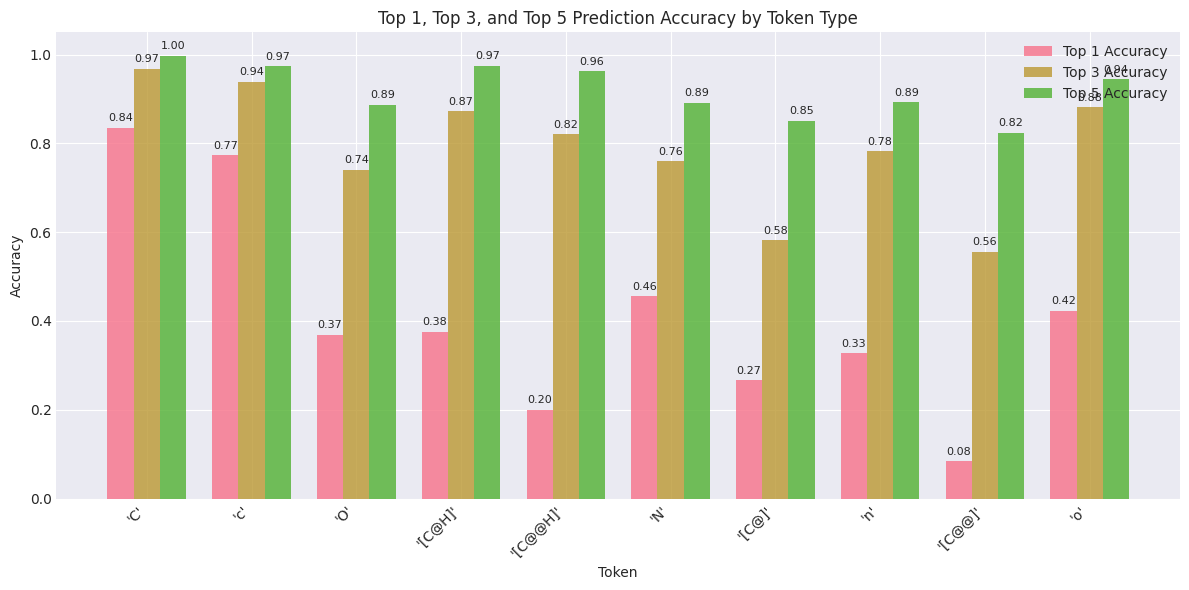

In [11]:
# Top 1, Top 3, and Top 5 Accuracy by Token Type
if len(results_df) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))

    # Get top tokens by frequency
    top_tokens = results_df["actual_token"].value_counts().head(10).index

    # Calculate Top 1 accuracy (is_correct)
    top1_accuracy = (
        results_df[results_df["actual_token"].isin(top_tokens)]
        .groupby("actual_token")["is_correct"]
        .mean()
    )

    # Calculate Top 3 and Top 5 accuracy
    def is_in_topk(row, k):
        # Get top k predictions from all_target_probs
        sorted_probs = sorted(
            row["all_target_probs"].items(), key=lambda x: x[1], reverse=True
        )[:k]
        topk_tokens = [token for token, _ in sorted_probs]
        return row["actual_token"] in topk_tokens

    results_df["in_top3"] = results_df.apply(lambda x: is_in_topk(x, 3), axis=1)
    results_df["in_top5"] = results_df.apply(lambda x: is_in_topk(x, 5), axis=1)

    top3_accuracy = (
        results_df[results_df["actual_token"].isin(top_tokens)]
        .groupby("actual_token")["in_top3"]
        .mean()
    )
    top5_accuracy = (
        results_df[results_df["actual_token"].isin(top_tokens)]
        .groupby("actual_token")["in_top5"]
        .mean()
    )

    # Prepare data for plotting
    x = np.arange(len(top_tokens))
    width = 0.25

    # Create bars
    bars1 = ax.bar(
        x - width, top1_accuracy[top_tokens], width, label="Top 1 Accuracy", alpha=0.8
    )
    bars2 = ax.bar(
        x, top3_accuracy[top_tokens], width, label="Top 3 Accuracy", alpha=0.8
    )
    bars3 = ax.bar(
        x + width, top5_accuracy[top_tokens], width, label="Top 5 Accuracy", alpha=0.8
    )

    # Customize plot
    ax.set_xlabel("Token")
    ax.set_ylabel("Accuracy")
    ax.set_title("Top 1, Top 3, and Top 5 Prediction Accuracy by Token Type")
    ax.set_xticks(x)
    ax.set_xticklabels([repr(t) for t in top_tokens], rotation=45, ha="right")
    ax.legend()
    ax.set_ylim(0, 1.05)

    # Add value labels on bars
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2.0,
                height + 0.01,
                f"{height:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    plt.tight_layout()
    plt.show()
else:
    print("No results to visualize.")

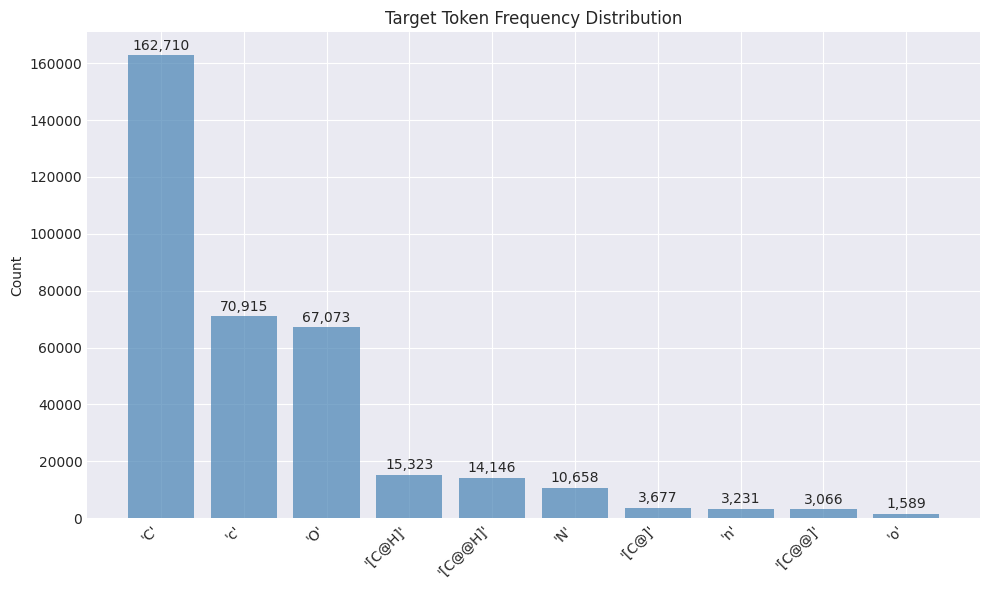

In [12]:
# Token Frequency Distribution
if len(results_df) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    token_counts = results_df["actual_token"].value_counts().head(10)
    bars = ax.bar(
        range(len(token_counts)), token_counts.values, alpha=0.7, color="steelblue"
    )

    ax.set_xticks(range(len(token_counts)))
    ax.set_xticklabels([repr(t) for t in token_counts.index], rotation=45, ha="right")
    ax.set_ylabel("Count")
    ax.set_title("Target Token Frequency Distribution")

    # Add value labels on bars
    for i, (bar, value) in enumerate(zip(bars, token_counts.values)):
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            value + 1000,
            f"{value:,}",
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()
else:
    print("No results to visualize.")

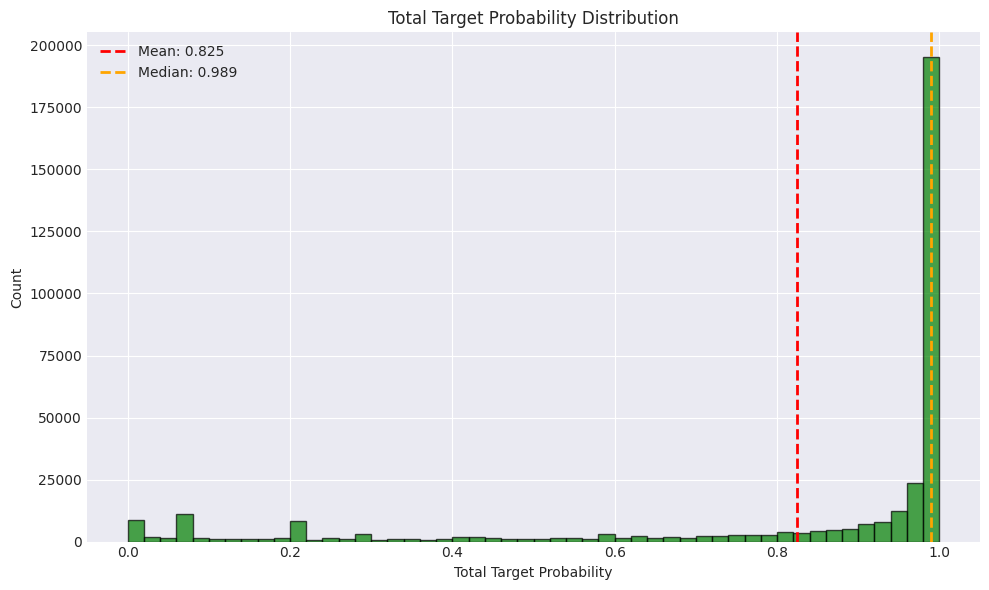

In [13]:
# Total Target Probability Distribution
if len(results_df) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    ax.hist(
        results_df["total_target_prob"],
        bins=50,
        alpha=0.7,
        color="green",
        edgecolor="black",
    )
    ax.set_xlabel("Total Target Probability")
    ax.set_ylabel("Count")
    ax.set_title("Total Target Probability Distribution")

    # Add mean line
    mean_prob = results_df["total_target_prob"].mean()
    ax.axvline(
        mean_prob,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {mean_prob:.3f}",
    )

    # Add median line
    median_prob = results_df["total_target_prob"].median()
    ax.axvline(
        median_prob,
        color="orange",
        linestyle="--",
        linewidth=2,
        label=f"Median: {median_prob:.3f}",
    )

    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No results to visualize.")

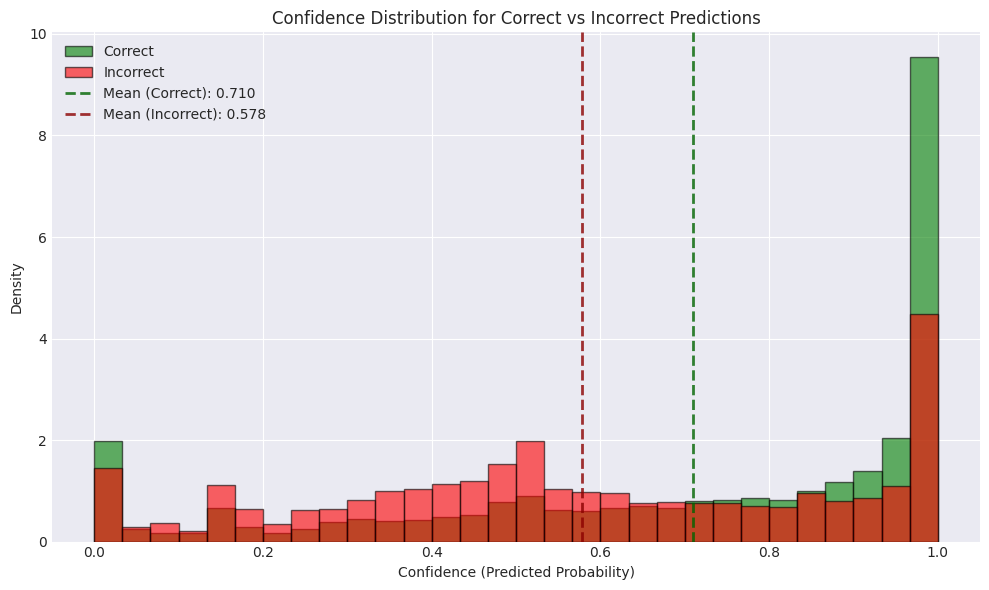

In [14]:
# Confidence Distribution
if len(results_df) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    # Plot confidence distributions for correct and incorrect predictions
    ax.hist(
        results_df[results_df["is_correct"]]["confidence"],
        bins=30,
        alpha=0.6,
        label="Correct",
        density=True,
        color="green",
        edgecolor="black",
    )
    ax.hist(
        results_df[~results_df["is_correct"]]["confidence"],
        bins=30,
        alpha=0.6,
        label="Incorrect",
        density=True,
        color="red",
        edgecolor="black",
    )

    ax.set_xlabel("Confidence (Predicted Probability)")
    ax.set_ylabel("Density")
    ax.set_title("Confidence Distribution for Correct vs Incorrect Predictions")
    ax.legend()

    # Add mean confidence values
    mean_correct = results_df[results_df["is_correct"]]["confidence"].mean()
    mean_incorrect = results_df[~results_df["is_correct"]]["confidence"].mean()

    ax.axvline(
        mean_correct,
        color="darkgreen",
        linestyle="--",
        linewidth=2,
        alpha=0.8,
        label=f"Mean (Correct): {mean_correct:.3f}",
    )
    ax.axvline(
        mean_incorrect,
        color="darkred",
        linestyle="--",
        linewidth=2,
        alpha=0.8,
        label=f"Mean (Incorrect): {mean_incorrect:.3f}",
    )

    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No results to visualize.")

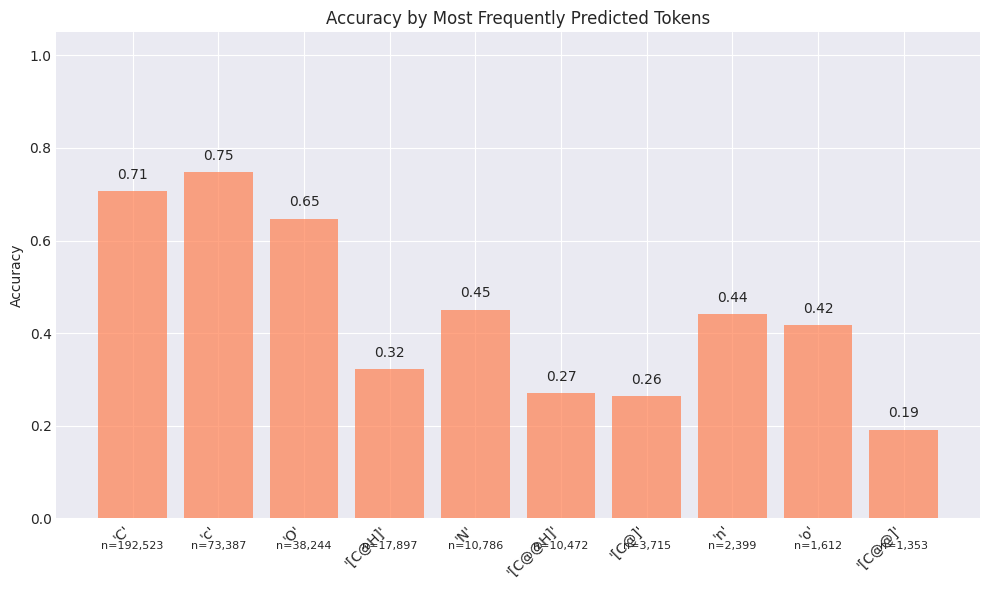

In [15]:
# Accuracy by Most Predicted Tokens
if len(results_df) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    # Get top predicted tokens and their accuracy
    top_predicted = results_df["predicted_token"].value_counts().head(10).index
    pred_accuracy = []
    pred_labels = []
    pred_counts = []

    for token in top_predicted:
        token_results = results_df[results_df["predicted_token"] == token]
        accuracy = token_results["is_correct"].mean()
        count = len(token_results)
        pred_accuracy.append(accuracy)
        pred_labels.append(repr(token))
        pred_counts.append(count)

    bars = ax.bar(range(len(pred_accuracy)), pred_accuracy, alpha=0.7, color="coral")
    ax.set_xticks(range(len(pred_accuracy)))
    ax.set_xticklabels(pred_labels, rotation=45, ha="right")
    ax.set_ylabel("Accuracy")
    ax.set_title("Accuracy by Most Frequently Predicted Tokens")
    ax.set_ylim(0, 1.05)

    # Add value labels on bars
    for i, (bar, value, count) in enumerate(zip(bars, pred_accuracy, pred_counts)):
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            value + 0.02,
            f"{value:.2f}",
            ha="center",
            va="bottom",
        )
        # Add count below the bar
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            -0.05,
            f"n={count:,}",
            ha="center",
            va="top",
            fontsize=8,
            rotation=0,
        )

    plt.tight_layout()
    plt.show()
else:
    print("No results to visualize.")

## Examples of Predictions


In [16]:
if len(results_df) > 0:
    print("=== Examples of Token Predictions ===")

    # Most confident correct predictions
    print("\nMost Confident Correct Predictions:")
    top_confident_correct = results_df[results_df["is_correct"]].nlargest(
        5, "confidence"
    )
    for idx, row in top_confident_correct.iterrows():
        print(f"  Input: {row['input_smiles']}")
        print(f"  Actual: {row['actual_token']} (prob: {row['actual_token_prob']:.4f})")
        print(
            f"  Predicted: {row['predicted_token']} (prob: {row['predicted_prob']:.4f})"
        )
        print(f"  Confidence: {row['confidence']:.4f}")
        print()

    # Most confident incorrect predictions
    print("\nMost Confident Incorrect Predictions:")
    top_confident_incorrect = results_df[~results_df["is_correct"]].nlargest(
        5, "confidence"
    )
    for idx, row in top_confident_incorrect.iterrows():
        print(f"  Input: {row['input_smiles']}")
        print(f"  Actual: {row['actual_token']} (prob: {row['actual_token_prob']:.4f})")
        print(
            f"  Predicted: {row['predicted_token']} (prob: {row['predicted_prob']:.4f})"
        )
        print(f"  Confidence: {row['confidence']:.4f}")
        print()

    # Low total target probability cases
    print("\nLow Total Target Probability Cases:")
    low_target_prob = results_df.nsmallest(5, "total_target_prob")
    for idx, row in low_target_prob.iterrows():
        print(f"  Input: {row['input_smiles']}")
        print(f"  Actual: {row['actual_token']} (prob: {row['actual_token_prob']:.4f})")
        print(f"  Total target prob: {row['total_target_prob']:.4f}")
        print()

    # Random examples
    print("\nRandom Examples:")
    random_examples = results_df.sample(min(5, len(results_df)))
    for idx, row in random_examples.iterrows():
        print(f"  Input: {row['input_smiles']}")
        print(f"  Actual: {row['actual_token']} (prob: {row['actual_token_prob']:.4f})")
        print(
            f"  Predicted: {row['predicted_token']} (prob: {row['predicted_prob']:.4f})"
        )
        print(f"  Correct: {row['is_correct']}")
        print()
else:
    print("No results to show examples.")

=== Examples of Token Predictions ===

Most Confident Correct Predictions:
  Input: CC[C@]1(CNC(=N)NC)C#CC[C@@H](Cc2ccc(O)c(OC3CCCC3)
  Actual: c (prob: 1.0000)
  Predicted: c (prob: 1.0000)
  Confidence: 1.0000

  Input: O=C1CCc2cc(c(O)c(OC3CCCC3)c2)Cc2ccc(CC(O)Cc3ccccc3)c(c2)Cc2cc[nH]c2NCC2=Cc3[nH]
  Actual: c (prob: 1.0000)
  Predicted: c (prob: 1.0000)
  Confidence: 1.0000

  Input: O=C1CCc2cc(c(O)c(OC3CCCC3)c2)Cc2ccc(CC(O)Cc3ccccc3)c(c2)Cc2cc[nH]c2NCC2=Cc3[nH]ccc3C(CC3C=Cc4c(O)
  Actual: c (prob: 1.0000)
  Predicted: c (prob: 1.0000)
  Confidence: 1.0000

  Input: CCCCC[C@@H](O)CC(=O)CCc1ccc(O)c(OCn2cc3[nH]cc(Cc4c(CO)ccc5c4C=CN[C@H]5N)c3
  Actual: c (prob: 1.0000)
  Predicted: c (prob: 1.0000)
  Confidence: 1.0000

  Input: CCCS(=O)(=O)N1C[C@H]2C[C@H](C1)c1ccc(-c3ccccc3CN3CCO
  Actual: C (prob: 1.0000)
  Predicted: C (prob: 1.0000)
  Confidence: 1.0000


Most Confident Incorrect Predictions:
  Input: COc1cc2c(cc1O)C1=C[C@H]3C[C@]4(CC[C@H]([C@H](CCCO)n5ccc6[nH]ccc65)C4)[C@H]4C[C@H]

In [17]:
if len(results_df) > 0:
    print("=== Summary Statistics ===")

    # Overall metrics
    total_samples = len(results_df)
    correct_predictions = results_df["is_correct"].sum()
    accuracy = correct_predictions / total_samples

    print(f"\nDataset: {DATA_FILE}")
    print(f"Total molecules sampled: {N_SAMPLES}")
    print(f"Total target contexts found: {total_samples}")
    print(f"Correct predictions: {correct_predictions}")
    print(f"Overall accuracy: {accuracy:.3f} ({accuracy * 100:.1f}%)")

    # Token-specific metrics
    print("\nToken-specific Results:")
    for token in results_df["actual_token"].value_counts().head(10).index:
        token_results = results_df[results_df["actual_token"] == token]
        if len(token_results) > 0:
            token_accuracy = token_results["is_correct"].mean()
            mean_prob = token_results["actual_token_prob"].mean()
            print(
                f"  {repr(token)}: {len(token_results)} samples, {token_accuracy:.3f} accuracy, {mean_prob:.4f} avg prob"
            )

    # Probability thresholds
    print("\nModel Confidence Analysis:")
    high_conf_threshold = 0.8
    med_conf_threshold = 0.6

    high_conf = results_df[results_df["predicted_prob"] >= high_conf_threshold]
    med_conf = results_df[
        (results_df["predicted_prob"] >= med_conf_threshold)
        & (results_df["predicted_prob"] < high_conf_threshold)
    ]
    low_conf = results_df[results_df["predicted_prob"] < med_conf_threshold]

    print(
        f"  High confidence (>={high_conf_threshold}): {len(high_conf)} samples, {high_conf['is_correct'].mean():.3f} accuracy"
    )
    print(
        f"  Medium confidence ({med_conf_threshold}-{high_conf_threshold}): {len(med_conf)} samples, {med_conf['is_correct'].mean():.3f} accuracy"
    )
    print(
        f"  Low confidence (<{med_conf_threshold}): {len(low_conf)} samples, {low_conf['is_correct'].mean():.3f} accuracy"
    )

    # Target awareness
    print("\nTarget Token Awareness Analysis:")
    mean_total_target = results_df["total_target_prob"].mean()
    high_target_awareness = results_df[results_df["total_target_prob"] >= 0.5]
    print(f"  Mean total target probability: {mean_total_target:.4f}")
    print(
        f"  Cases with high target awareness (>=0.5): {len(high_target_awareness)} ({len(high_target_awareness) / total_samples * 100:.1f}%)"
    )
    if len(high_target_awareness) > 0:
        print(
            f"  Accuracy in high target awareness cases: {high_target_awareness['is_correct'].mean():.3f}"
        )

    # Model statistics
    print("\nModel Information:")
    print(f"  Model checkpoint: {MODEL_CHECKPOINT}")
    print(f"  Tokenizer: {TOKENIZER_NAME}")
    print(f"  Target pattern: {TARGET_TOKEN_PATTERN}")
    print(f"  Target tokens: {TARGET_TOKENS}")
    print(f"  Canonicalization: {CANONICALIZE}")
    print(f"  Batch size: {BATCH_SIZE}")
    print(f"  Random seed: {RANDOM_SEED}")

else:
    print("No results to summarize.")

=== Summary Statistics ===

Dataset: ../../data/coconut_chiral_test.smi
Total molecules sampled: 10000
Total target contexts found: 352388
Correct predictions: 231951
Overall accuracy: 0.658 (65.8%)

Token-specific Results:


  'C': 162710 samples, 0.835 accuracy, 0.5765 avg prob
  'c': 70915 samples, 0.773 accuracy, 0.6554 avg prob
  'O': 67073 samples, 0.369 accuracy, 0.3185 avg prob
  '[C@H]': 15323 samples, 0.376 accuracy, 0.3186 avg prob
  '[C@@H]': 14146 samples, 0.200 accuracy, 0.2574 avg prob
  'N': 10658 samples, 0.456 accuracy, 0.4035 avg prob
  '[C@]': 3677 samples, 0.267 accuracy, 0.1800 avg prob
  'n': 3231 samples, 0.327 accuracy, 0.2574 avg prob
  '[C@@]': 3066 samples, 0.084 accuracy, 0.1853 avg prob
  'o': 1589 samples, 0.424 accuracy, 0.4245 avg prob

Model Confidence Analysis:
  High confidence (>=0.8): 159214 samples, 0.776 accuracy
  Medium confidence (0.6-0.8): 53646 samples, 0.648 accuracy
  Low confidence (<0.6): 139528 samples, 0.528 accuracy

Target Token Awareness Analysis:
  Mean total target probability: 0.8251
  Cases with high target awareness (>=0.5): 296458 (84.1%)
  Accuracy in high target awareness cases: 0.660

Model Information:
  Model checkpoint: ../../model/coconut_ch

## Chiral Center Prediction Analysis

This section analyzes whether the model correctly predicts when a carbon atom should be a chiral center (i.e., should have @ or @@ chirality markers).

In [18]:
def analyze_chiral_center_prediction(model, tokenizer, smiles_list, n_samples=1000):
    """
    Analyze model's ability to predict when a carbon should be a chiral center.

    This function:
    1. Finds positions where the next token is a carbon (C or c)
    2. Checks if that carbon is actually part of a chiral center in the full SMILES
    3. Evaluates if the model assigns high probability to chiral tokens ([C@H], [C@@H], etc.)
    """

    # Define chiral tokens
    chiral_tokens = ["[C@H]", "[C@@H]", "[C@]", "[C@@]"]
    chiral_token_ids = {
        token: tokenizer.encode(token, add_special_tokens=False)[0]
        for token in chiral_tokens
        if token in tokenizer.get_vocab()
    }

    # Define carbon tokens
    carbon_tokens = ["C", "c"]
    carbon_token_ids = {
        token: tokenizer.encode(token, add_special_tokens=False)[0]
        for token in carbon_tokens
    }

    results = []

    # Sample molecules
    sampled_smiles = random.sample(smiles_list, min(n_samples, len(smiles_list)))

    for smiles in tqdm(sampled_smiles, desc="Analyzing chiral center predictions"):
        try:
            # Canonicalize SMILES
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                continue
            canonical_smiles = Chem.MolToSmiles(
                mol, isomericSmiles=True, canonical=True
            )

            # Tokenize
            tokens = tokenizer.tokenize(canonical_smiles)
            if tokens is None:
                encoded = tokenizer.encode(canonical_smiles, add_special_tokens=False)
                tokens = [tokenizer.decode([token_id]) for token_id in encoded]

            # Find positions where next token should be evaluated
            for i in range(len(tokens) - 1):
                next_token = tokens[i + 1]

                # Check if next token is a carbon-related token
                is_next_carbon = next_token in carbon_tokens
                is_next_chiral = next_token in chiral_tokens

                if not (is_next_carbon or is_next_chiral):
                    continue

                # Get model predictions for this position
                prefix = "".join(tokens[: i + 1])
                input_ids = tokenizer.encode(
                    prefix, add_special_tokens=True, truncation=True, max_length=512
                )
                input_ids = torch.tensor([input_ids]).to("cuda")

                with torch.no_grad():
                    outputs = model({"input_ids": input_ids, "labels": input_ids})
                    logits = outputs.logits[0, -1, :]
                    probs = F.softmax(logits, dim=-1)

                # Calculate probabilities for different token types
                carbon_prob = sum(
                    probs[carbon_token_ids[t]].item() for t in carbon_tokens
                )
                chiral_prob = sum(
                    probs[chiral_token_ids[t]].item()
                    for t in chiral_tokens
                    if t in chiral_token_ids
                )

                # Get actual token probability
                actual_token_id = tokenizer.encode(
                    next_token, add_special_tokens=False
                )[0]
                actual_prob = probs[actual_token_id].item()

                # Determine if the actual token is chiral
                actual_is_chiral = next_token in chiral_tokens

                # Store result
                result = {
                    "smiles": canonical_smiles,
                    "position": i,
                    "prefix": prefix,
                    "actual_token": next_token,
                    "actual_is_chiral": actual_is_chiral,
                    "actual_prob": actual_prob,
                    "carbon_prob": carbon_prob,
                    "chiral_prob": chiral_prob,
                    "total_carbon_chiral_prob": carbon_prob + chiral_prob,
                    "chiral_ratio": chiral_prob / (carbon_prob + chiral_prob)
                    if (carbon_prob + chiral_prob) > 0
                    else 0,
                }

                results.append(result)

        except Exception as e:
            continue

    return pd.DataFrame(results)


# Run the analysis
print("Analyzing model's understanding of chiral centers...")
chiral_analysis_df = analyze_chiral_center_prediction(
    model, tokenizer, smiles_list, n_samples=2000
)
print(f"Analyzed {len(chiral_analysis_df)} carbon positions")

Analyzing model's understanding of chiral centers...


Analyzing chiral center predictions: 100%|██████████| 2000/2000 [04:27<00:00,  7.48it/s]

Analyzed 52115 carbon positions


In [19]:
# Analyze the results
if len(chiral_analysis_df) > 0:
    print("=== Chiral Center Prediction Analysis ===")
    
    # Separate chiral and non-chiral carbons
    chiral_carbons = chiral_analysis_df[chiral_analysis_df['actual_is_chiral']]
    non_chiral_carbons = chiral_analysis_df[~chiral_analysis_df['actual_is_chiral']]
    
    print(f"\nTotal carbon positions analyzed: {len(chiral_analysis_df)}")
    print(f"Actual chiral carbons: {len(chiral_carbons)} ({len(chiral_carbons)/len(chiral_analysis_df)*100:.1f}%)")
    print(f"Non-chiral carbons: {len(non_chiral_carbons)} ({len(non_chiral_carbons)/len(chiral_analysis_df)*100:.1f}%)")
    
    # Model's chiral probability assignment
    print("\n--- Model's Chiral Probability Assignment ---")
    print(f"For actual chiral carbons:")
    print(f"  Mean chiral probability: {chiral_carbons['chiral_prob'].mean():.4f}")
    print(f"  Mean carbon probability: {chiral_carbons['carbon_prob'].mean():.4f}")
    print(f"  Mean chiral ratio: {chiral_carbons['chiral_ratio'].mean():.4f}")
    
    print(f"\nFor non-chiral carbons:")
    print(f"  Mean chiral probability: {non_chiral_carbons['chiral_prob'].mean():.4f}")
    print(f"  Mean carbon probability: {non_chiral_carbons['carbon_prob'].mean():.4f}")
    print(f"  Mean chiral ratio: {non_chiral_carbons['chiral_ratio'].mean():.4f}")
    
    # Thresholds for chiral prediction
    chiral_ratio_threshold = 0.5  # If chiral_ratio > 0.5, model "predicts" it should be chiral
    
    # Calculate accuracy metrics
    chiral_analysis_df['model_predicts_chiral'] = chiral_analysis_df['chiral_ratio'] > chiral_ratio_threshold
    
    # True positives, false positives, etc.
    tp = ((chiral_analysis_df['actual_is_chiral']) & (chiral_analysis_df['model_predicts_chiral'])).sum()
    fp = ((~chiral_analysis_df['actual_is_chiral']) & (chiral_analysis_df['model_predicts_chiral'])).sum()
    tn = ((~chiral_analysis_df['actual_is_chiral']) & (~chiral_analysis_df['model_predicts_chiral'])).sum()
    fn = ((chiral_analysis_df['actual_is_chiral']) & (~chiral_analysis_df['model_predicts_chiral'])).sum()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\n--- Model Performance (threshold={chiral_ratio_threshold}) ---")
    print(f"True Positives: {tp}")
    print(f"False Positives: {fp}")
    print(f"True Negatives: {tn}")
    print(f"False Negatives: {fn}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1 Score: {f1:.3f}")
    
    # High confidence predictions
    high_conf_threshold = 0.8
    high_conf_chiral = chiral_analysis_df[chiral_analysis_df['chiral_ratio'] > high_conf_threshold]
    high_conf_non_chiral = chiral_analysis_df[chiral_analysis_df['chiral_ratio'] < (1-high_conf_threshold)]
    
    print(f"\n--- High Confidence Predictions ---")
    if len(high_conf_chiral) > 0:
        accuracy_when_high_chiral = high_conf_chiral['actual_is_chiral'].mean()
        print(f"When model is {high_conf_threshold*100:.0f}%+ confident it's chiral: {accuracy_when_high_chiral:.3f} accuracy ({len(high_conf_chiral)} cases)")
    
    if len(high_conf_non_chiral) > 0:
        accuracy_when_high_non_chiral = (~high_conf_non_chiral['actual_is_chiral']).mean()
        print(f"When model is {high_conf_threshold*100:.0f}%+ confident it's NOT chiral: {accuracy_when_high_non_chiral:.3f} accuracy ({len(high_conf_non_chiral)} cases)")
    
else:
    print("No results to analyze")

=== Chiral Center Prediction Analysis ===

Total carbon positions analyzed: 52115
Actual chiral carbons: 7129 (13.7%)
Non-chiral carbons: 44986 (86.3%)

--- Model's Chiral Probability Assignment ---
For actual chiral carbons:
  Mean chiral probability: 0.5583
  Mean carbon probability: 0.2911
  Mean chiral ratio: 0.6256

For non-chiral carbons:
  Mean chiral probability: 0.0677
  Mean carbon probability: 0.6930
  Mean chiral ratio: 0.0951

--- Model Performance (threshold=0.5) ---
True Positives: 4468
False Positives: 2805
True Negatives: 42181
False Negatives: 2661
Precision: 0.614
Recall: 0.627
F1 Score: 0.620

--- High Confidence Predictions ---
When model is 80%+ confident it's chiral: 0.770 accuracy (4326 cases)
When model is 80%+ confident it's NOT chiral: 0.963 accuracy (38717 cases)


/tmp/44041.1.interactive/ipykernel_2288179/1786979146.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_to_plot, labels=['Chiral\n(chiral prob)', 'Non-chiral\n(chiral prob)',


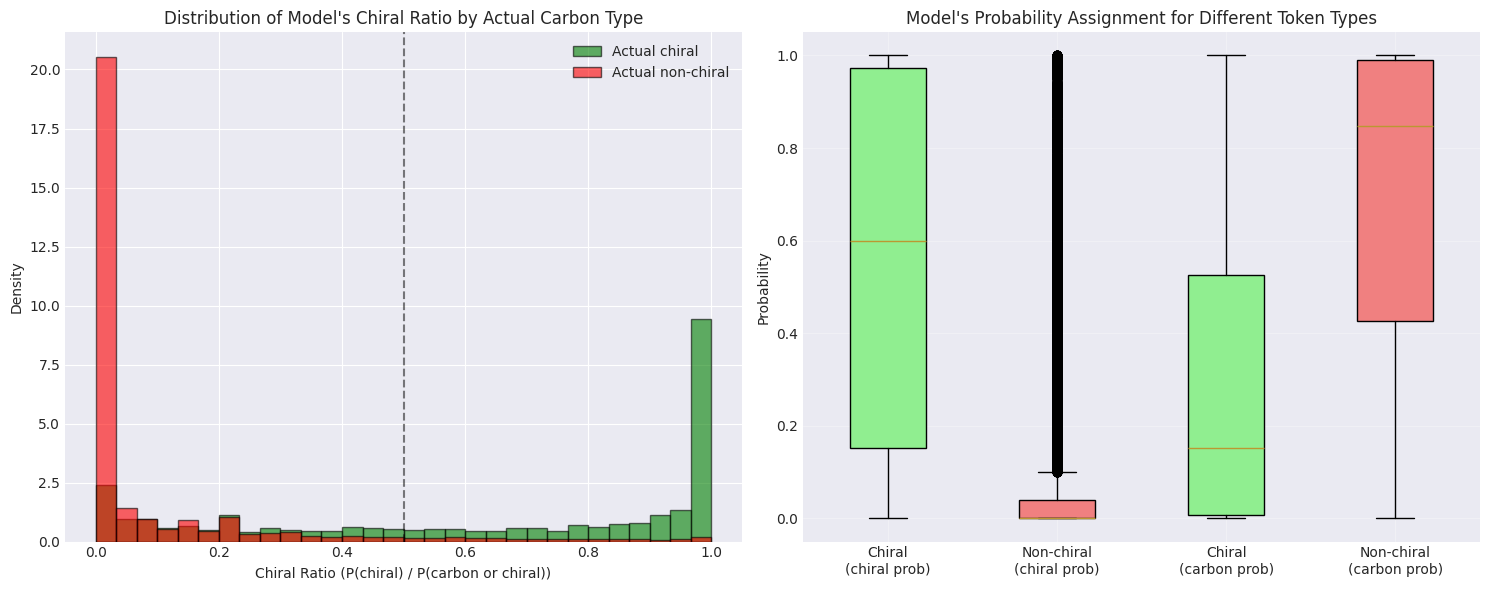


--- Distribution Statistics ---
Chiral carbons with chiral_ratio > 0.5: 4468 / 7129 (62.7%)
Non-chiral carbons with chiral_ratio < 0.5: 42181 / 44986 (93.8%)


In [20]:
# Visualize chiral ratio distributions
if len(chiral_analysis_df) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Chiral ratio distribution by actual type
    chiral_carbons = chiral_analysis_df[chiral_analysis_df['actual_is_chiral']]
    non_chiral_carbons = chiral_analysis_df[~chiral_analysis_df['actual_is_chiral']]
    
    ax1.hist(chiral_carbons['chiral_ratio'], bins=30, alpha=0.6, label='Actual chiral', 
             density=True, color='green', edgecolor='black')
    ax1.hist(non_chiral_carbons['chiral_ratio'], bins=30, alpha=0.6, label='Actual non-chiral', 
             density=True, color='red', edgecolor='black')
    
    ax1.set_xlabel('Chiral Ratio (P(chiral) / P(carbon or chiral))')
    ax1.set_ylabel('Density')
    ax1.set_title('Distribution of Model\'s Chiral Ratio by Actual Carbon Type')
    ax1.legend()
    ax1.axvline(0.5, color='black', linestyle='--', alpha=0.5, label='Decision threshold')
    
    # Plot 2: Box plot of chiral probabilities
    data_to_plot = [
        chiral_carbons['chiral_prob'],
        non_chiral_carbons['chiral_prob'],
        chiral_carbons['carbon_prob'],
        non_chiral_carbons['carbon_prob']
    ]
    
    bp = ax2.boxplot(data_to_plot, labels=['Chiral\n(chiral prob)', 'Non-chiral\n(chiral prob)',
                                           'Chiral\n(carbon prob)', 'Non-chiral\n(carbon prob)'],
                     patch_artist=True)
    
    # Color the boxes
    colors = ['lightgreen', 'lightcoral', 'lightgreen', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax2.set_ylabel('Probability')
    ax2.set_title('Model\'s Probability Assignment for Different Token Types')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print some statistics
    print("\n--- Distribution Statistics ---")
    print(f"Chiral carbons with chiral_ratio > 0.5: {(chiral_carbons['chiral_ratio'] > 0.5).sum()} / {len(chiral_carbons)} ({(chiral_carbons['chiral_ratio'] > 0.5).mean()*100:.1f}%)")
    print(f"Non-chiral carbons with chiral_ratio < 0.5: {(non_chiral_carbons['chiral_ratio'] < 0.5).sum()} / {len(non_chiral_carbons)} ({(non_chiral_carbons['chiral_ratio'] < 0.5).mean()*100:.1f}%)")